# The within-lepton-jet dimuon vertex: a signal-preserving fake-killer for 4mu

**The problem this addresses.** The isolated 4mu corner -- the signal region of
every isolation ABCD plane (notebooks 02, 04) -- is dominated by an
instrumental fake: pairs of muon-system-only (DSA) tracks that the lepton-jet
clustering packages as a dimuon but that do not come from a common decay. This
population is what makes every 4mu isolation ABCD non-close, and Monte Carlo
does not reproduce it (it is a detector/reconstruction artifact, not a
physics process), so its *rejection* can only be measured on data.

**What MC can answer, and does here.** The discriminant proposed to remove the
fake is a physical one: require the two muons of the leading lepton-jet to fit
a common **within-LJ Kalman vertex with good quality** (normChi2 < 5). A real
dark-photon dimuon has a genuine common vertex however displaced; a
combinatoric fake does not. The one thing that could disqualify this cut is if
it also removed *signal* -- especially displaced signal, the search's target.
That is a pure MC question, and this notebook answers it: the vertex
requirement keeps the large majority of signal at every lifetime, unlike a
distance-of-closest-approach cut, which does not.

**The vertex objects.** LLPNanoAOD stores three refitted dimuon-vertex
collections -- `DSAMuonVertex`, `PatMuonVertex`, `PatDSAMuonVertex` -- each
carrying `normChi2`, a 3D `dca`, and `vxy`/`vxySigma`, with muon indices that
match a vertex to a lepton-jet's constituents. The best (lowest-normChi2)
within-LJ vertex defines the discriminant. Only successful fits are stored, so
"no within-LJ vertex" is itself meaningful -- but *how often the fake lacks
one* is the data measurement, deferred to the continuation. Everything below
is signal and background MC; no collision data is read.

In [1]:
import glob, re
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import coffea.util as cu

plt.style.use(hep.style.CMS)

MCDIR = "/uscms_data/d3/murtazas/abcd_plane_study_pairres_local"   # MC-only stage
# Regenerate from EOS (contains NO collision data):
#   root://cmseos.fnal.gov//store/group/lpcmetx/SIDM/coffea_outputs/murtazas/abcd_plane_study_pairres

def _mc_files(pattern):
    fs = sorted(glob.glob(MCDIR + "/" + pattern))
    for f in fs:
        assert "DoubleMuon" not in f and "/Data/" not in f, "refusing data file: " + f
    return fs

def load(pattern, hname):
    out = None
    for f in _mc_files(pattern):
        o = cu.load(f); o = o.get("out", o)
        for ds in o.values():
            h = ds["hists"][hname]
            out = h.copy() if out is None else out + h
    return out

def arr(hist_obj, ch):
    hch = hist_obj[{"channel": ch}]
    names = [a.name for a in hch.axes]
    v = hch.view(); v = v["value"] if v.dtype.names else v
    i = names.index("parity"); v = v.sum(axis=i); names.pop(i)
    return v, names

def red(v, names, keep, sel=None):
    sl = [slice(None)] * v.ndim
    for k, s in (sel or {}).items():
        sl[names.index(k)] = s
    vv = v[tuple(sl)]
    return vv.sum(axis=tuple(i for i, n in enumerate(names) if n not in keep))

def ptok(t): return float(t.replace("p", "."))
def parse(name):
    m = re.match(r"4Mu_(\d+)GeV_([0-9p]+)GeV_([0-9p]+)mm", name)
    return int(m.group(1)), ptok(m.group(2)), ptok(m.group(3))

SIG4 = [f.split("/")[-1].replace(".coffea", "") for f in _mc_files("4Mu_*.coffea")]
print("MC-only load. signal 4Mu points:", len(SIG4), "| data files seen: 0 (guarded)")

MC-only load. signal 4Mu points: 13 | data files seen: 0 (guarded)


## 1. Signal keeps a good within-LJ vertex

The `abcd_vdca_4mu` histogram carries a vertex-quality category `vcat` for the
leading mu-LJ: **no within-LJ vertex** / **good (normChi2 < 5)** / **poor
(normChi2 >= 5)**. For each signal point we take the fraction of events whose
leading lepton-jet has a good vertex -- the efficiency of the fake-killer on
signal.

In [2]:
EFF = {}
for name in SIG4:
    v, names = arr(load(name + ".coffea", "abcd_vdca_4mu"), "4mu_abcd_scan")
    vcat = red(v, names, keep=["vcat"])          # [no-vertex, good, poor]
    tot = vcat.sum()
    # DCA<0.05 efficiency from the vdca axis (bins 1:5 span [0,0.05) cm)
    vdca = red(v, names, keep=["vdca"])
    EFF[name] = {"novtx": vcat[0] / tot, "good": vcat[1] / tot, "poor": vcat[2] / tot,
                 "dca05": vdca[1:5].sum() / tot}
    mb, mdp, ct = parse(name)
    print("%-30s  no-vtx %.2f  good(chi2<5) %.2f  poor %.2f   |  DCA<0.05 %.2f"
          % (name, EFF[name]["novtx"], EFF[name]["good"], EFF[name]["poor"], EFF[name]["dca05"]))

g12 = [EFF[n]["good"] for n in SIG4 if abs(parse(n)[1] - 1.2) < 1e-6]
print("\n1.2 GeV points: chi2<5 signal efficiency spans %.2f - %.2f" % (min(g12), max(g12)))

4Mu_1000GeV_1p2GeV_0p0096mm     no-vtx 0.03  good(chi2<5) 0.79  poor 0.18   |  DCA<0.05 0.92
4Mu_1000GeV_1p2GeV_0p96mm       no-vtx 0.13  good(chi2<5) 0.69  poor 0.18   |  DCA<0.05 0.55
4Mu_1000GeV_1p2GeV_9p6mm        no-vtx 0.21  good(chi2<5) 0.62  poor 0.17   |  DCA<0.05 0.35
4Mu_100GeV_1p2GeV_0p096mm       no-vtx 0.00  good(chi2<5) 0.93  poor 0.07   |  DCA<0.05 0.98
4Mu_100GeV_1p2GeV_96p0mm        no-vtx 0.17  good(chi2<5) 0.73  poor 0.10   |  DCA<0.05 0.22
4Mu_100GeV_1p2GeV_9p6mm         no-vtx 0.08  good(chi2<5) 0.78  poor 0.14   |  DCA<0.05 0.53
4Mu_500GeV_0p25GeV_0p4mm        no-vtx 0.26  good(chi2<5) 0.63  poor 0.12   |  DCA<0.05 0.39
4Mu_500GeV_0p25GeV_4p0mm        no-vtx 0.30  good(chi2<5) 0.58  poor 0.12   |  DCA<0.05 0.24
4Mu_500GeV_1p2GeV_0p019mm       no-vtx 0.01  good(chi2<5) 0.85  poor 0.14   |  DCA<0.05 0.95


4Mu_500GeV_1p2GeV_19p0mm        no-vtx 0.23  good(chi2<5) 0.62  poor 0.15   |  DCA<0.05 0.29
4Mu_500GeV_1p2GeV_1p9mm         no-vtx 0.12  good(chi2<5) 0.70  poor 0.18   |  DCA<0.05 0.53
4Mu_500GeV_5p0GeV_80p0mm        no-vtx 0.07  good(chi2<5) 0.76  poor 0.17   |  DCA<0.05 0.33
4Mu_500GeV_5p0GeV_8p0mm         no-vtx 0.03  good(chi2<5) 0.78  poor 0.19   |  DCA<0.05 0.62

1.2 GeV points: chi2<5 signal efficiency spans 0.62 - 0.93


The good-vertex efficiency is high and only mildly lifetime-dependent: for the
nominal 1.2 GeV dark photon ~0.79-0.93 for prompt points and ~0.62-0.78 across
the displaced grid, with the collimated 0.25 GeV point lower throughout
(~0.58-0.63, where two resolvable muons are harder to reconstruct at all). The
fake-killer keeps the majority of signal at every lifetime -- this is the
property that makes it usable.

## 2. Why it is signal-safe: vertex quality vs distance of closest approach

The key is *what the cut tests*. A vertex-fit normChi2 asks whether the two
tracks are mutually compatible with a common point -- a question whose answer
does not depend on how far that point is from the beamline, so a genuine
displaced dimuon fits well at any lifetime. A distance-of-closest-approach
(DCA) cut instead asks how close the two tracks pass, a *resolution*-limited
quantity that degrades as the muons become more displaced and are
reconstructed from muon-system hits alone. The figure contrasts the two on
signal: the chi2 requirement declines gently with lifetime while a
DCA < 0.05 cm cut collapses -- which is why the vertex-quality cut is the
fake-killer and the DCA is only a diagnostic (notebook 07).

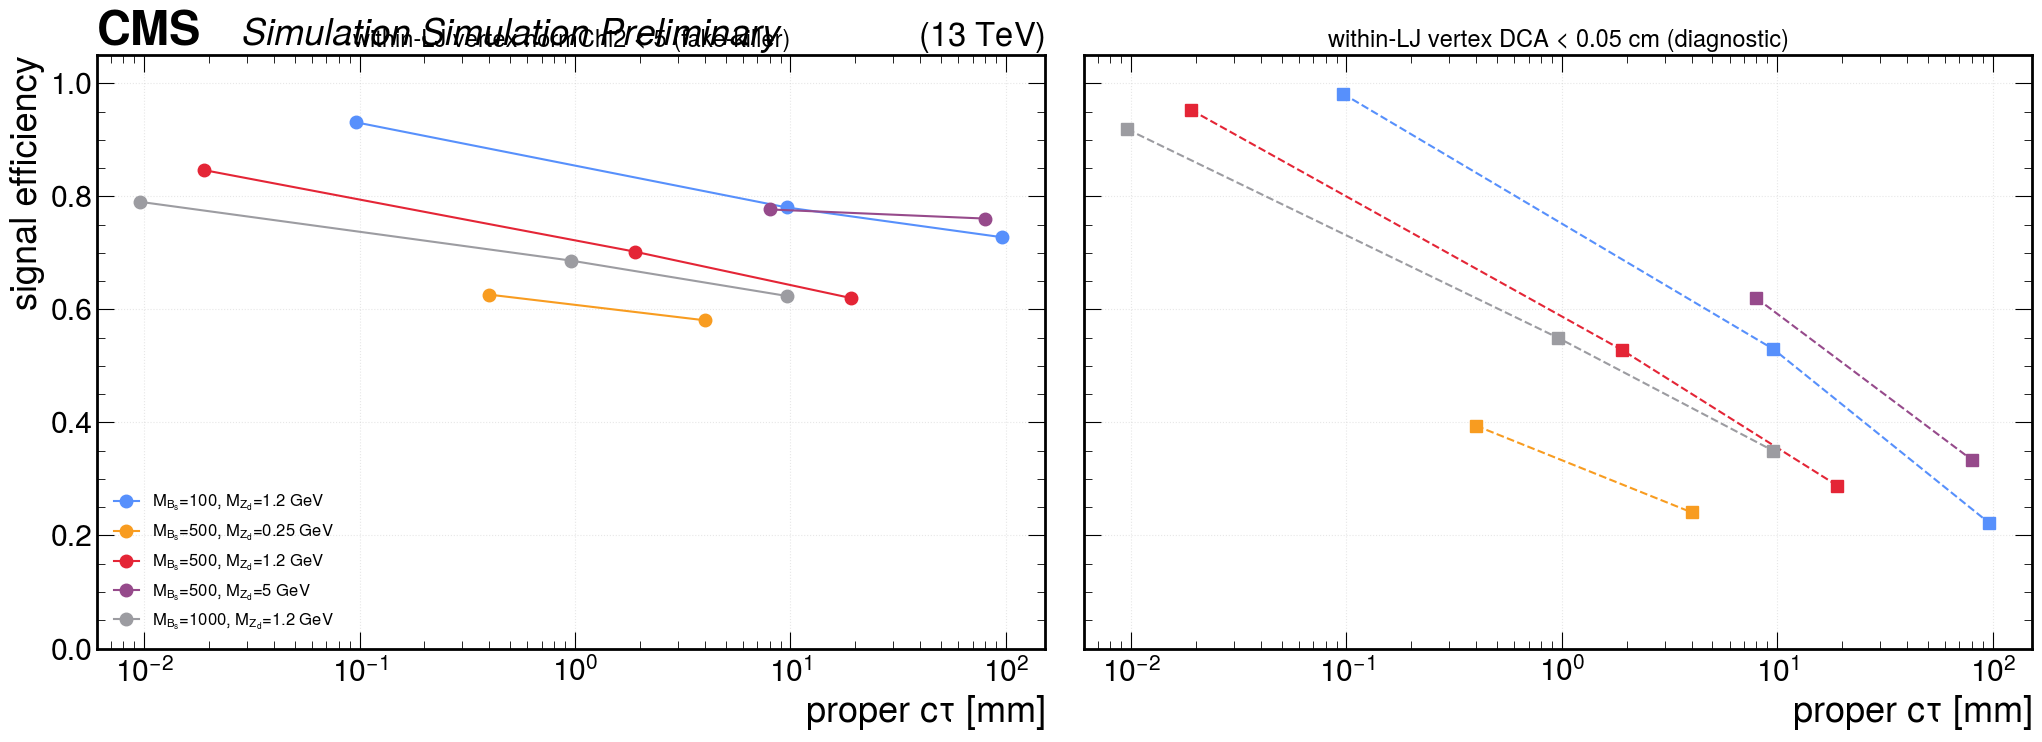

In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(21, 8), sharey=True)
series = {}
for name in SIG4:
    mb, mdp, ct = parse(name)
    series.setdefault((mb, mdp), []).append((ct, name))
for (mb, mdp), pts in sorted(series.items()):
    pts.sort(); cts = [p[0] for p in pts]
    a1.plot(cts, [EFF[p[1]]["good"] for p in pts], "o-", ms=9,
            label=r"$M_{B_s}$=%d, $M_{Z_d}$=%.2g GeV" % (mb, mdp))
    a2.plot(cts, [EFF[p[1]]["dca05"] for p in pts], "s--", ms=9)
a1.set_title("within-LJ vertex normChi2 < 5 (fake-killer)", fontsize=17)
a2.set_title("within-LJ vertex DCA < 0.05 cm (diagnostic)", fontsize=17)
for a in (a1, a2):
    a.set_xscale("log"); a.set_xlabel(r"proper $c\tau$ [mm]"); a.set_ylim(0, 1.05); a.grid(alpha=0.3)
a1.set_ylabel("signal efficiency"); a1.legend(fontsize=12)
hep.cms.label("Simulation Preliminary", data=False, ax=a1)
plt.tight_layout(); plt.show()

## 3. What is deferred to the data continuation

MC establishes the **signal cost** of the fake-killer (small, shown above). It
cannot establish its **rejection power**, because the population the cut is
designed to remove -- the DSA-only combinatoric fake of the isolated 4mu
corner -- does not exist in Monte Carlo. Whether that fake indeed lacks a
good within-LJ vertex (so the cut removes it) is a *data-sideband*
measurement, and it is the natural next step for whoever continues this study:
select the isolated no-signal region in data, and measure the good-vertex rate
there. The expectation, from the physical argument, is that the fake is
vertex-less at high rate while genuine dimuons are not; confirming that on data
turns the fake-killer into the definition of the clean 4mu region on which the
mass fit (notebook 07) runs.

## Takeaways

* The within-LJ dimuon **vertex-quality requirement (normChi2 < 5) is
  signal-preserving**: for the nominal 1.2 GeV dark photon ~79-93% efficient
  for prompt signal and ~62-78% across the displaced grid (lower, ~58-63%, for
  the collimated 0.25 GeV point), declining only gently with lifetime.
* It is signal-safe *because* a vertex fit tests track compatibility, not
  displacement -- unlike a DCA cut, whose signal efficiency collapses with
  lifetime and which is therefore only a diagnostic.
* Its **rejection of the isolated-corner fake is a data measurement** (the
  fake is MC-invisible), and defines the clean 4mu region for the windowed
  mass fit -- the data-side continuation of this study.